def objective(trial):

    alpha_1 = trial.suggest_float("alpha_1",-7,-1)
    alpha_2 = trial.suggest_float("alpha_2",-40,-10)
    bias   = trial.suggest_float("bias",0,0.5)
    slope  = trial.suggest_float("slope",10,17)
    gamma = trial.suggest_float("gamma", 0,1.5)
    #delta = trial.suggest_float("delta", 0,10)

In [47]:


import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

SEED = 1234

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from project.loader import Loader
from project.CROP.models.crop2 import Crop2 
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection


# FASHION_PARAMS={'alpha_1': -0.19868397094671308, 
#         'alpha_2': -13.487772584723764, 
#         'bias': 0.2025587756051315, 
#         'slope': 12.603926712541048, 
#         'gamma': 1.348637346498534}


dataset = "fashion"

inter=256
lat=64

data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_train = data["x_train"]
x_train_1 = data["x_train_1"]
y_train = data["y_train"]
y_train_1 = data["y_train_1"]
ITERATIONS = 30

c = Crop3EstimationCorrection(predictor=predictor,lat=lat,inter=inter,dataset=dataset)
def objective(trial):

    alpha_1 = trial.suggest_float("alpha_1", -10, -5)
    alpha_2 = trial.suggest_float("alpha_2", -20, -5)
    bias    = trial.suggest_float("bias", 0.1, 0.4)
    slope   = trial.suggest_float("slope", 13, 20)
    gamma   = trial.suggest_float("gamma", 1, 2)
    delta = trial.suggest_float("delta", 0, 1)
    n_images = 1000

    try:

        # Selección de datos
        X0 = x_train[:n_images]
        Y0 = y_train[:n_images]

        X1 = x_train_1[:n_images]
        Y1 = y_train_1[:n_images]

        # Randomización independiente para (x_train, y_train)
        idx0 = np.random.permutation(len(X0))
        X0 = X0[idx0]
        Y0 = Y0[idx0]

        # Randomización independiente para (x_train_1, y_train_1)
        idx1 = np.random.permutation(len(X1))
        X1 = X1[idx1]
        Y1 = Y1[idx1]

        metrics = c.unmix(
            X0,
            X1,
            Y0,
            Y1,
            params={'gamma': gamma, 'alpha_1':alpha_1, 'alpha_2':alpha_2, 'bias':bias, 'slope':slope,'delta':delta},
            #params={'gamma': gamma,'delta':delta},
            iterations=ITERATIONS,
            show_metrics=False
        )

        return float(metrics["ssim"][0])

    except Exception as e:
        print(f"Error: {e}")
        return float("-inf")  # mejor para maximize
    



Usando fashion como dataset


In [48]:
import optuna


# Creamos un estudio de minimización
study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials=100) # Probamos 30 combinaciones

# Mostramos los mejores resultados
print("\n📊 Mejores hiperparámetros encontrados:")
print(study.best_trials)

#mejores parametros para Crop3MaskCorrection  optimizando acc_both.

#params={'delta': 3.817760761786454}

#mejores parametros para Crop3MaskCorrection  optimizando SSIM.

#params={'gamma': 1.4197414603476595, 'delta': 5.593244163014582, 'threshold': 11}
#----------------------------------------------------------------------

#mejores parametros para Crop3EstimationCorrection  optimizando acc_both.
#params={'gamma': 1.265852455556597, 'delta': 0.3429787390624981}

#mejores parametros para Crop3EstimationCorrection  optimizando SSIM.
#params={'gamma': 1.5420520651370637, 'delta': 0.4771720136717561}



[I 2026-06-04 00:57:18,320] A new study created in memory with name: no-name-a95c626e-f793-4b33-969c-5b31359bef7e
[I 2026-06-04 00:57:22,093] Trial 0 finished with value: 0.6802524924278259 and parameters: {'alpha_1': -7.227045753312072, 'alpha_2': -17.56270910146051, 'bias': 0.29378076286935806, 'slope': 19.685746406355115, 'gamma': 1.617832393561966, 'delta': 0.3196927071724921}. Best is trial 0 with value: 0.6802524924278259.
[I 2026-06-04 00:57:26,270] Trial 1 finished with value: 0.6811711192131042 and parameters: {'alpha_1': -7.968812928702701, 'alpha_2': -19.490638125649067, 'bias': 0.2620205018677493, 'slope': 15.803727908632755, 'gamma': 1.2863125216076146, 'delta': 0.2405992358238358}. Best is trial 1 with value: 0.6811711192131042.
[I 2026-06-04 00:57:30,049] Trial 2 finished with value: 0.6779953241348267 and parameters: {'alpha_1': -7.791065062065659, 'alpha_2': -14.41801304468569, 'bias': 0.18259150829222448, 'slope': 14.077664824173503, 'gamma': 1.0909560821944426, 'delt


📊 Mejores hiperparámetros encontrados:
[FrozenTrial(number=69, state=1, values=[0.6986865401268005], datetime_start=datetime.datetime(2026, 6, 4, 1, 1, 58, 787278), datetime_complete=datetime.datetime(2026, 6, 4, 1, 2, 3, 41432), params={'alpha_1': -9.941125499313165, 'alpha_2': -16.852458549802762, 'bias': 0.18973246824243017, 'slope': 19.666498382269456, 'gamma': 1.6344295866300675, 'delta': 0.40844153736349087}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'alpha_1': FloatDistribution(high=-5.0, log=False, low=-10.0, step=None), 'alpha_2': FloatDistribution(high=-5.0, log=False, low=-20.0, step=None), 'bias': FloatDistribution(high=0.4, log=False, low=0.1, step=None), 'slope': FloatDistribution(high=20.0, log=False, low=13.0, step=None), 'gamma': FloatDistribution(high=2.0, log=False, low=1.0, step=None), 'delta': FloatDistribution(high=1.0, log=False, low=0.0, step=None)}, trial_id=69, value=None)]


Mejores parámetros para Fashion (256,64) 
params={'alpha_1': -0.19868397094671308, 'alpha_2': -13.487772584723764, 'bias': 0.2025587756051315, 'slope': 12.603926712541048, 'gamma': 1.348637346498534}

In [15]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 19.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [50]:
optuna.visualization.plot_slice(study, params=['alpha_1','alpha_2','bias','slope','gamma','delta'])
#optuna.visualization.plot_slice(study, params=['gamma','delta'])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                   14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
                                   26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,
                                   38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
                                   50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61,
                                   62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73,
                                   74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
                                   86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97,
                                   98, 99],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': True},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [-7.227045753312072, -7.968812928702701, -7.791065062065659,
                    -9.315932586073734, -9.833426963307735, -6.719916710794458,
                    -9.8181702117074, -9.359747790415417, -5.278945431295236,
                    -8.632379596743018, -5.788367894433508, -9.971706528559487,
                    -8.79443304894363, -8.935637552543257, -9.398368542194087,
                    -8.285145095947211, -8.552210590989805, -8.370415803285614,
                    -6.984810833846266, -8.166213023671858, -6.372040069402589,
                    -8.140029732037908, -7.537815798241207, -7.549816897229155,
                    -7.646436966916827, -7.142930392139853, -8.127809305813209,
                    -6.609942847331006, -6.1456283612802896, -7.210911325948765,
                    -7.498871954160526, -8.182772030270767, -7.9457966397858675,
                    -7.971729707584271, -9.035645932646815, -8.331795369236493,
                    -8.349420142296651, -8.364571213222122, -8.46350307283129,
                    -9.08122271130566, -9.12564515035578, -9.171940956057984,
                    -9.164116004470928, -9.503177424873579, -8.707151097082287,
                    -9.6341878376614, -9.192063506187516, -8.918925204639912,
                    -9.620631213785211, -8.696737831460627, -9.230273767808933,
                    -8.512680251924913, -8.841689915240856, -8.465017381143078,
                    -9.052429031072538, -9.830154921116241, -9.393355042628851,
                    -7.8941877788001005, -8.643119099870349, -8.669730384461939,
                    -9.013464040650712, -8.835133630909121, -8.819303496729077,
                    -9.572460464736434, -5.143967234013051, -9.96230561061401,
                    -9.697677644091204, -9.482388459806971, -5.075966076270587,
                    -9.941125499313165, -9.85133188742965, -9.949312816183292,
                    -5.970015174544766, -9.319496134051604, -9.985095255816377,
                    -9.296079639805441, -9.709095177348999, -5.658324809629713,
                    -5.377803972956764, -5.494311229313818, -5.029426651238058,
                    -9.533891843974267, -5.2107096771468715, -5.6396005091029835,
                    -5.1789222246404325, -5.35084230561767, -5.3236661006344175,
                    -5.7450127251916685, -5.4891878763470485, 

# Iteraciones sobre MNIST
- Primera Iteración:
- - alpha_1 = trial.suggest_float("alpha_1",-10,0)
    alpha_2 = trial.suggest_float("alpha_2",-30,0)
    bias   = trial.suggest_float("bias",0,1)
    slope  = trial.suggest_float("slope",10,25)
    gamma = trial.suggest_float("gamma", 0,2)

- resultados
- - params={'alpha_1': -2.8139725406009246, 'alpha_2': -8.632162233789037, 'bias': 0.169795038046944, 'slope': 11.054193895768261, 'gamma': 0.2744991886904259}

- imagen:
- - all_params_mnist_256_64_inicial.png

- Segunda iteracion
- - alpha_1 = trial.suggest_float("alpha_1",-5,0)
    alpha_2 = trial.suggest_float("alpha_2",-15,-5)
    bias   = trial.suggest_float("bias",0,0.5)
    slope  = trial.suggest_float("slope",8,15)
    gamma = trial.suggest_float("gamma", 0,1)

resultados
params={'alpha_1': -1.7514625237292865, 'alpha_2': -11.044116800075729, 'bias': 0.16993664999002342, 'slope': 14.009433505123264, 'gamma': 0.26454965328440383}

- imagen:
- - all_params_mnist_256_64_segunda.png


Tercera iteracion
alpha_1 = trial.suggest_float("alpha_1",-3,0)
    alpha_2 = trial.suggest_float("alpha_2",-14,-7)
    bias   = trial.suggest_float("bias",0,0.4)
    slope  = trial.suggest_float("slope",12,16)
    gamma = trial.suggest_float("gamma", 0,0.5)
    #delta = trial.suggest_float("delta", 0,10)
    
resultados    
params={'alpha_1': -2.3190234576754354, 'alpha_2': -12.838123415324027, 'bias': 0.19697246489532128, 'slope': 12.82188747160999, 'gamma': 0.12771716754388948}

imagen
- - all_params_mnist_256_64_tercera.png
    
Cuarta iteracion


    alpha_1 = trial.suggest_float("alpha_1",-3,0)
    alpha_2 = trial.suggest_float("alpha_2",-14,-10)
    bias   = trial.suggest_float("bias",0,0.3)
    slope  = trial.suggest_float("slope",12,15)
    gamma = trial.suggest_float("gamma", 0,0.4)

resultados
params={'alpha_1': -1.9017812743215168, 'alpha_2': -10.622014647572298, 'bias': 0.16036806623232167, 'slope': 14.329065676286392, 'gamma': 0.11754080633935388}

imagen
- - all_params_mnist_256_64_cuarta.png

quinta inter

    alpha_1 = trial.suggest_float("alpha_1",-1,0)
    alpha_2 = trial.suggest_float("alpha_2",-14,-10)
    bias   = trial.suggest_float("bias",0.1,0.3)
    slope  = trial.suggest_float("slope",13,15)
    gamma = trial.suggest_float("gamma", 0,0.3)


    resultados:
    params={'alpha_1': -0.7554316822000634, 'alpha_2': -10.89528732608377, 'bias': 0.22514286684741838, 'slope': 14.234751072589363, 'gamma': 0.22036818257574708}
imagen
- - all_params_mnist_256_64_cuarta.png



sexta iteracion

    alpha_1 = trial.suggest_float("alpha_1",-1,-0.5)
    alpha_2 = trial.suggest_float("alpha_2",-14,-10)
    bias   = trial.suggest_float("bias",0.1,0.3)
    slope  = trial.suggest_float("slope",13,15)
    gamma = trial.suggest_float("gamma", 0.1,0.4)





resultados
    params={'alpha_1': -0.7318194523692176, 'alpha_2': -13.298799839110004, 'bias': 0.1912805895468515, 'slope': 14.103192574012466, 'gamma': 0.3081613950943278},



Iteraciones para Fashion mnist

- Priemra 

    alpha_1 = trial.suggest_float("alpha_1",-10,0)
    alpha_2 = trial.suggest_float("alpha_2",-30,-0)
    bias   = trial.suggest_float("bias",0,1)
    slope  = trial.suggest_float("slope",5,15)
    gamma = trial.suggest_float("gamma", 0,2)
    #delta = trial.suggest_float("delta", 0,10)
    resutlados
    params={'alpha_1': -5.6351666203254105, 'alpha_2': -24.28709500314875, 'bias': 0.14484791167604535, 'slope': 13.939925900987108, 'gamma': 0.6424203988720422}

    imagen
     all_params_fmnist_256_64_inicial.png





    alpha_1 = trial.suggest_float("alpha_1",-7,-1)
    alpha_2 = trial.suggest_float("alpha_2",-40,-10)
    bias   = trial.suggest_float("bias",0,0.5)
    slope  = trial.suggest_float("slope",10,17)
    gamma = trial.suggest_float("gamma", 0,1.5)
    #delta = trial.suggest_float("delta", 0,10)
resultados:
params={'alpha_1': -2.061123361422079, 'alpha_2': -16.221279262682753, 'bias': 0.16462141344654385, 'slope': 14.60581699061414, 'gamma': 0.6769392287079429}
imagen
     all_params_fmnist_256_64_segunda.png




tercera iter
    alpha_1 = trial.suggest_float("alpha_1",-4,-1)
    alpha_2 = trial.suggest_float("alpha_2",-20,-10)
    bias   = trial.suggest_float("bias",0,0.3)
    slope  = trial.suggest_float("slope",13,17)
    gamma = trial.suggest_float("gamma", 0,1.25)


resultados
params={'alpha_1': -3.2494599828826285, 'alpha_2': -10.690247283215475, 'bias': 0.1513523084826905, 'slope': 14.982576796486406, 'gamma': 0.704747584330756}

imagen
     all_params_fmnist_256_64_tercera.png


Cuarta
    alpha_1 = trial.suggest_float("alpha_1",-4,-2)
    alpha_2 = trial.suggest_float("alpha_2",-15,-7)
    bias   = trial.suggest_float("bias",0.1,0.3)
    slope  = trial.suggest_float("slope",13,16)
    gamma = trial.suggest_float("gamma", 0.2,1)
    resultadods
    params={'alpha_1': -3.59669471752203, 'alpha_2': -8.275043853312345, 'bias': 0.15864544872127676, 'slope': 15.13542995563637, 'gamma': 0.49709981864416336}
    

Crop3 

    alpha_1 = trial.suggest_float("alpha_1", -5, 0)
    alpha_2 = trial.suggest_float("alpha_2", -20, -5)
    bias    = trial.suggest_float("bias", 0, 1)
    slope   = trial.suggest_float("slope", 12, 20)
    gamma   = trial.suggest_float("gamma", 0, 2)
    delta = trial.suggest_float("delta", 0, 2)
-----------------------------------------------------------
segunda

    alpha_1 = trial.suggest_float("alpha_1", -5, 0)
    alpha_2 = trial.suggest_float("alpha_2", -20, 0)
    bias    = trial.suggest_float("bias", 0, 0.5)
    slope   = trial.suggest_float("slope", 10, 20)
    gamma   = trial.suggest_float("gamma", 0.5, 2)
    delta = trial.suggest_float("delta", 0, 1)
    n_images = 1000
    
 ------------------------------------------------------
    alpha_1 = trial.suggest_float("alpha_1", -4, 0)
    alpha_2 = trial.suggest_float("alpha_2", -20, -5)
    bias    = trial.suggest_float("bias", 0, 0.4)
    slope   = trial.suggest_float("slope", 10, 20)
    gamma   = trial.suggest_float("gamma", 0.5, 2)
    delta = trial.suggest_float("delta", 0, 1)


Crop 3 para ssim

    alpha_1 = trial.suggest_float("alpha_1", -10, 0)
    alpha_2 = trial.suggest_float("alpha_2", -20, -0)
    bias    = trial.suggest_float("bias", 0, 1)
    slope   = trial.suggest_float("slope", 10, 20)
    gamma   = trial.suggest_float("gamma", 0, 2)
    delta = trial.suggest_float("delta", 0, 2)


        alpha_1 = trial.suggest_float("alpha_1", -10, -5)
    alpha_2 = trial.suggest_float("alpha_2", -20, -5)
    bias    = trial.suggest_float("bias", 0, 0.5)
    slope   = trial.suggest_float("slope", 10, 20)
    gamma   = trial.suggest_float("gamma", 0.7, 2)
    delta = trial.suggest_float("delta", 0, 1.5)

# Verificacion

Usando fashion como dataset


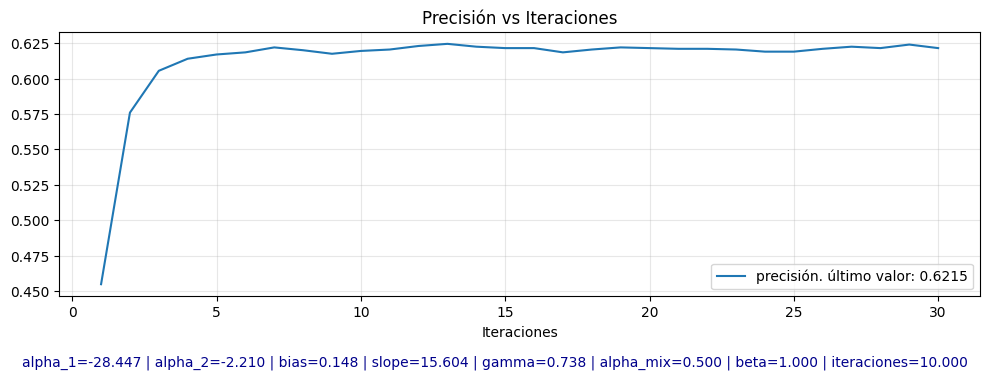

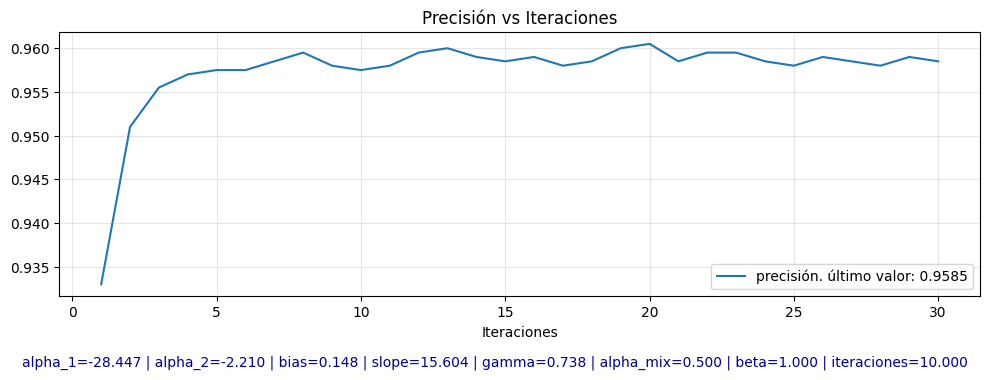

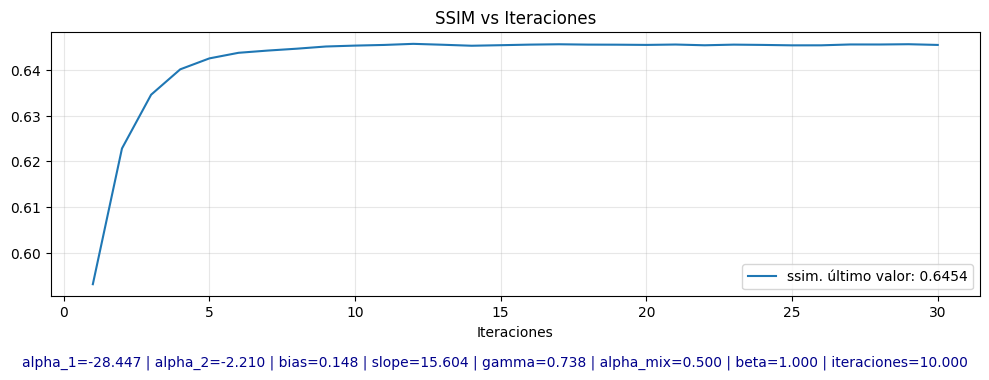

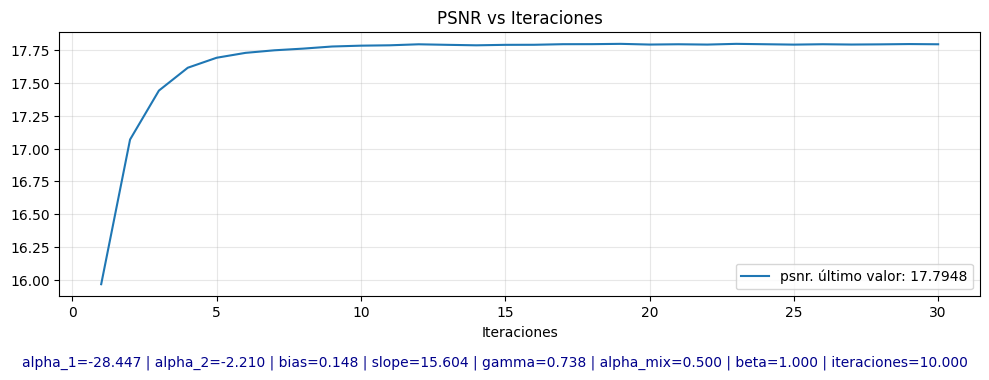


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -28.447
alpha_2     : -2.210
bias        : 0.148
slope       : 15.604
gamma       : 0.738
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 17.795  std:2.507
mask_bpsnr       : mean: 10.459  std:1.404
ssim             : mean: 0.645  std:0.100
acc_at_least_one : 0.959
acc_both         : 0.622



In [ ]:
#cosas viejas
# #parámetros optimizados para ssim
# ssim_params={'bias': 0.3490758398711943, 'slope': 23.79981809771706, 'alpha_1': -2.5004348572265864, 'alpha_2': -16.418488717733673, 'gamma': 0.2612293606781744}
# #parámetros optimizados para recon_bpsnr
# recon_bpsnr_params={'bias': 0.1753106428802752, 'slope': 20.088006577214188, 'alpha_1': -4.3120902863188775, 'alpha_2': -31.469765177549906, 'gamma': 0.7367839585631266}
# #parámetros optimizados para mask_bpsnr
# mask_bpsnr_params={'bias': 0.4032196468954787, 'slope': 10.773311686035228, 'alpha_1': -4.487552303478556, 'alpha_2': -7.255734630588293, 'gamma': 0.44933267965195817}#parámetros optimizados para acc_both
# #parámetros optimizados para acc_both
# acc_both_params={'bias': 0.21716868437244724, 'slope': 19.437646607877017, 'alpha_1': -0.13863158439804657, 'alpha_2': -10.463749682840565, 'gamma': 0.5392507616026618}
# ## solo optimizanddo gamma
# acc_both_gamma = {'gamma': 0.7435064454594396}

# ##recon_bpsnr lat128_inter_512
# params_recon_bpsnr_lat128_inter_512={'gamma': 0.9519615639307367}#optimizacion para recon_bpsnr
# params_acc_both_lat128_inter_512 = {'gamma': 0.3012911033494221} # optimización de acc
# #acc_both bias y slope y gamma 


import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

SEED = 1234

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from project.loader import Loader
from project.CROP.models.crop2 import Crop2 
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection

dataset = "mnist"

inter=512
lat=128
data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_train = data["x_test"]
x_train_1 = data["x_test_1"]
y_train = data["y_test"]
y_train_1 = data["y_test_1"]
ITERATIONS = 30

n_images=2000

c = Crop2(predictor=predictor,lat=lat,inter=inter,dataset=dataset)

for g in range(-1,1,10):

    metrics = c.unmix(
                x_train[:n_images],
                x_train_1[:n_images],
                y_train[:n_images],
                y_train_1[:n_images],
                params={'gamma': g},
                iterations=ITERATIONS,
                show_metrics=True,
                show_all_curves=True
            )